In [13]:
import sys
from pathlib import Path
from difflib import get_close_matches
import scipy.io
from scipy.stats import ks_2samp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import gaussian_kde

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "axes.labelsize": 11,
    "font.size": 11,
    "figure.dpi": 120,
})

AXIS_NAMES = [
    "fool_hero",
    "angel_demon",
    "trad_adventurer",
    "lone_wolf_diva",
    "outcast_soph",
    "brute_geek",
]

mat_path = '../datasets/archetypometricsdata2000.mat'

In [14]:
# Load mat file (70 MB — load once)
mat = scipy.io.loadmat(str(mat_path), simplify_cells=True)

# --- Extract story names ---
unique_stories = list(mat['data_stories']['storyverses'])
story_lower    = {s: s.lower().strip() for s in unique_stories}

story_imdb = pd.read_csv('../prepared_data/story_imdb_mapping.csv')
archetype_space = mat["data_archetype_space"]["character_component_norms"]
ds = mat["data_stories"]
story_names = ds["storyverses"]                   # (341,) array of strings
story_char_idx = ds["storycharacterindices"]      # (341,) array of 1-based index arrays

story_index = {
    story_names[i]: (story_char_idx[i] - 1)      # convert to 0-based
    for i in range(len(story_names))
}

genres    = story_imdb.groupby("story_name")["imdb_genres"].first().fillna("")
is_comedy = genres.str.contains("Comedy")
is_drama  = genres.str.contains("Drama")
pure      = is_comedy ^ is_drama
genre_labels  = is_comedy[pure].astype(int)

# add hand-labeled data
hl = pd.read_csv('../prepared_data/hand_labels.csv')
hl = hl.dropna(subset=["label"])
hl = hl[hl["label"].astype(str).str.strip().isin(["0", "1", "0.0", "1.0"])]
hl["label"] = hl["label"].astype(float).astype(int)
hl = hl.set_index("story_name")["label"]
# Merge: hand labels take precedence, then fill with IMDB-derived labels
genre_labels = hl.combine_first(genre_labels).astype(int)
axis_labels = AXIS_NAMES[:6]
rows = []
for story_name, is_comedy in genre_labels.items():
    if story_name not in story_index:
        continue

    char_idx = np.atleast_1d(story_index[story_name])     # 0-based; scalar → array
    scores   = archetype_space[:6, char_idx]         # (n_axes, n_chars)

    n_chars = len(char_idx)
    row = {"story_name": story_name, "is_comedy": int(is_comedy), "cast_size": n_chars}

    for j, axis in enumerate(axis_labels):
        row[f"{axis}_mean"] = scores[j].mean()
        # ddof=0: summarising the actual cast, not estimating a population
        row[f"{axis}_std"] = scores[j].std(ddof=0)

    rows.append(row)
df = pd.DataFrame(rows).set_index("story_name")

# Put cast_size and is_comedy last for readability
meta = [c for c in ["cast_size", "is_comedy"] if c in df.columns]
feat = [c for c in df.columns if c not in meta]
df = df[feat + meta]


df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 247 entries, (500) Days of Summer to Yellowstone
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fool_hero_mean        247 non-null    float64
 1   fool_hero_std         247 non-null    float64
 2   angel_demon_mean      247 non-null    float64
 3   angel_demon_std       247 non-null    float64
 4   trad_adventurer_mean  247 non-null    float64
 5   trad_adventurer_std   247 non-null    float64
 6   lone_wolf_diva_mean   247 non-null    float64
 7   lone_wolf_diva_std    247 non-null    float64
 8   outcast_soph_mean     247 non-null    float64
 9   outcast_soph_std      247 non-null    float64
 10  brute_geek_mean       247 non-null    float64
 11  brute_geek_std        247 non-null    float64
 12  cast_size             247 non-null    int64  
 13  is_comedy             247 non-null    int64  
dtypes: float64(12), int64(2)
memory usage: 28.9+ KB


In [15]:
genre_labels.value_counts()

label
0    160
1     87
Name: count, dtype: int64

In [16]:
comedy = df[df['is_comedy'] == 1]
drama  = df[df['is_comedy'] == 0]

feature_cols = [c for c in df.columns if c != 'is_comedy']
results = []

for col in feature_cols:
    stat, pval = ks_2samp(comedy[col].values, drama[col].values)
    results.append({'feature': col, 'ks_stat': stat, 'p_value': pval})

ks_df = (pd.DataFrame(results)
           .sort_values('ks_stat', ascending=False)
           .reset_index(drop=True))

ks_df['significant'] = ks_df['p_value'] < 0.05
ks_df.round(4)

,feature,ks_stat,p_value,significant
0,trad_adventurer_mean,0.3554,0.0000,True
1,fool_hero_mean,0.2985,0.0001,True
2,lone_wolf_diva_mean,0.2759,0.0003,True
3,outcast_soph_std,0.1783,0.0476,True
4,angel_demon_mean,0.1761,0.0520,False
5,trad_adventurer_std,0.1600,0.0976,False
6,angel_demon_std,0.1448,0.1666,False
7,brute_geek_mean,0.1070,0.4954,False
8,fool_hero_std,0.1037,0.5355,False
9,outcast_soph_mean,0.1007,0.5724,False


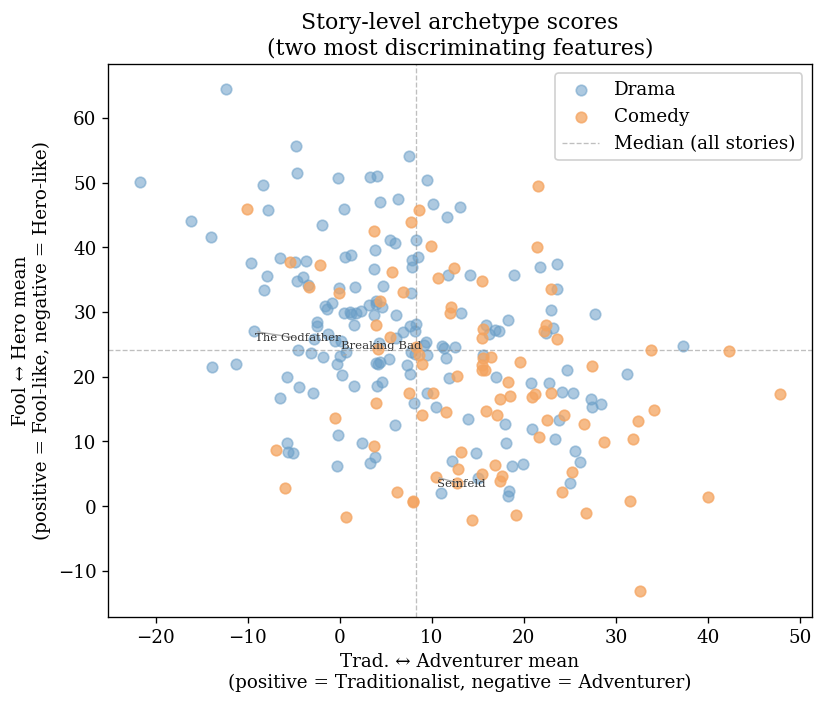

Stories per quadrant:
trad_pos  Trad+ / Fool+  Trad+ / Fool-  Trad- / Fool+  Trad- / Fool-
genre                                                               
Comedy               16             47             14             10
Drama                27             33             66             34


In [17]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    drama['trad_adventurer_mean'], drama['fool_hero_mean'],
    color='#6A9EC7', alpha=0.55, s=40, label='Drama', zorder=2
)
ax.scatter(
    comedy['trad_adventurer_mean'], comedy['fool_hero_mean'],
    color='#F4A460', alpha=0.75, s=40, label='Comedy', zorder=3
)

# Label a few recognisable stories
label_stories = {
    'Seinfeld': (0.1, -1.5), 'The Godfather': (0.1, -1.5),
    'Breaking Bad': (0.1, 1.2), '30 Rock': (-4, -1.5),
    'Schindler\'s List': (0.5, 0.5),
}
for story, (dx, dy) in label_stories.items():
    if story in df.index:
        x = df.loc[story, 'trad_adventurer_mean']
        y = df.loc[story, 'fool_hero_mean']
        ax.annotate(story, (x, y), (x + dx, y + dy),
                    fontsize=7, color='#333333',
                    arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.8))

ax.axvline(df['trad_adventurer_mean'].median(), color='grey',
           lw=0.8, ls='--', alpha=0.5, label='Median (all stories)')
ax.axhline(df['fool_hero_mean'].median(), color='grey', lw=0.8, ls='--', alpha=0.5)

ax.set_xlabel('Trad. ↔ Adventurer mean\n(positive = Traditionalist, negative = Adventurer)')
ax.set_ylabel('Fool ↔ Hero mean\n(positive = Fool-like, negative = Hero-like)')
ax.set_title('Story-level archetype scores\n(two most discriminating features)')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.show()

# Print how many of each genre fall in each quadrant
q = pd.DataFrame({
    'trad_pos': df['trad_adventurer_mean'] > df['trad_adventurer_mean'].median(),
    'fool_pos': df['fool_hero_mean'] > df['fool_hero_mean'].median(),
    'genre': df['is_comedy'].map({1: 'Comedy', 0: 'Drama'})
})
print("Stories per quadrant:")
print(pd.crosstab(q['genre'],
                  q['trad_pos'].map({True:'Trad+', False:'Trad-'}).str.cat(
                  q['fool_pos'].map({True:'Fool+', False:'Fool-'}), sep=' / ')))

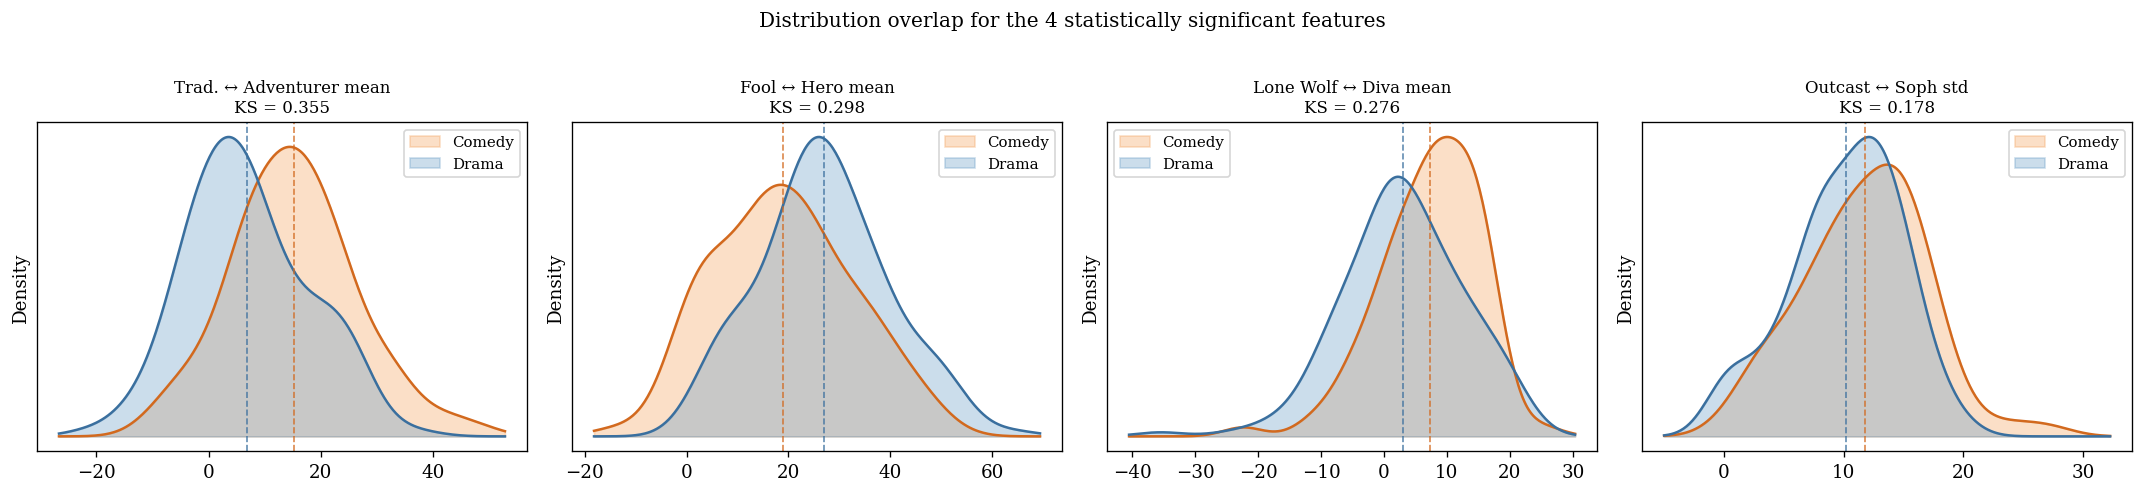

In [19]:
sig_features = ['trad_adventurer_mean', 'fool_hero_mean', 'lone_wolf_diva_mean', 'outcast_soph_std']
sig_labels   = ['Trad. ↔ Adventurer mean', 'Fool ↔ Hero mean', 'Lone Wolf ↔ Diva mean', 'Outcast ↔ Soph std']
sig_ks       = ks_df.set_index('feature').loc[sig_features, 'ks_stat'].round(3).values

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, feat, label, ks in zip(axes, sig_features, sig_labels, sig_ks):
    c_vals = comedy[feat].values
    d_vals = drama[feat].values
    x = np.linspace(min(c_vals.min(), d_vals.min()) - 5,
                    max(c_vals.max(), d_vals.max()) + 5, 300)

    kde_c = gaussian_kde(c_vals, bw_method=0.4)
    kde_d = gaussian_kde(d_vals, bw_method=0.4)

    ax.fill_between(x, kde_c(x), alpha=0.35, color='#F4A460', label='Comedy')
    ax.fill_between(x, kde_d(x), alpha=0.35, color='#6A9EC7', label='Drama')
    ax.plot(x, kde_c(x), color='#D2691E', lw=1.5)
    ax.plot(x, kde_d(x), color='#3A6F9E', lw=1.5)

    ax.axvline(c_vals.mean(), color='#D2691E', lw=1, ls='--', alpha=0.8)
    ax.axvline(d_vals.mean(), color='#3A6F9E', lw=1, ls='--', alpha=0.8)

    ax.set_title(f'{label}\nKS = {ks}', fontsize=10)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.set_yticks([])

plt.suptitle('Distribution overlap for the 4 statistically significant features',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()